# Fugue Backend Benchmark — Iceberg Dimension Tables

Benchmark SELECT query performance across 5 Fugue backends (Pandas, DuckDB, Spark, Dask, Ray)
on 4 benchmark tables varying in width (20 vs 200 columns) and row count (500K vs 1M).

## Prerequisites
Run the Airflow DAG `Insert_Benchmark_Data_To_Iceberg` first to populate the `benchmark` namespace.

## 1. Connect to Iceberg & Load Tables

In [2]:
import time
import pandas as pd
from pyiceberg.catalog import load_catalog

catalog = load_catalog(
    "rest",
    **{
        "uri": "http://iceberg-rest:8181",
        "s3.endpoint": "http://minio:9000",
        "s3.access-key-id": "minioadmin",
        "s3.secret-access-key": "minioadmin",
        "s3.region": "us-east-1",
    }
)

TABLE_NAMES = [
    "small_dim_100k",  # 20 cols, 100K rows
    "large_dim_100k",  # 200 cols, 100K rows
    "small_dim_200k",  # 20 cols, 200K rows
    "large_dim_200k",  # 200 cols, 200K rows
]

# Load all tables as Pandas DataFrames via PyIceberg -> Arrow -> Pandas
tables = {}
for name in TABLE_NAMES:
    fqn = f"benchmark.{name}"
    _start = time.time()
    tables[name] = catalog.load_table(fqn).scan().to_pandas()
    elapsed = time.time() - _start
    rows, cols = tables[name].shape
    print(f"{name}: {rows:,} rows x {cols} cols (loaded in {elapsed:.2f}s)")

small_dim_100k: 100,000 rows x 10 cols (loaded in 0.25s)
large_dim_100k: 100,000 rows x 50 cols (loaded in 0.52s)
small_dim_200k: 200,000 rows x 10 cols (loaded in 0.29s)
large_dim_200k: 200,000 rows x 50 cols (loaded in 1.05s)


## 3. Setup Fugue & Benchmark Harness

## 2. Configuration

In [3]:
# Set to False to skip Dask/Ray (useful when running in memory-constrained environments)
INCLUDE_DASK = False
INCLUDE_RAY = False

for name, enabled in [("Dask", INCLUDE_DASK), ("Ray", INCLUDE_RAY)]:
    print(f"{name} backend: {'ENABLED' if enabled else 'DISABLED (skipped during benchmark)'}")

Dask backend: DISABLED (skipped during benchmark)
Ray backend: DISABLED (skipped during benchmark)


In [4]:
import fugue.api as fa

ALL_ENGINES = [(None, "Pandas"), ("duckdb", "DuckDB"), ("spark", "Spark"), ("dask", "Dask"), ("ray", "Ray")]

# Filter engines based on configuration
active = [(e, l) for e, l in ALL_ENGINES
          if (l != "Dask" or INCLUDE_DASK) and (l != "Ray" or INCLUDE_RAY)]
ENGINES = [e for e, l in active]
ENGINE_LABELS = [l for e, l in active]

QUERY = """
SELECT *
FROM data
"""


def run_benchmark(table_name, df, engine, engine_label):
    """Run a SELECT * query via Fugue and return elapsed time in seconds."""
    start = time.time()
    result = fa.fugue_sql(QUERY, data=df, engine=engine)
    # Materialize result to Pandas to ensure execution is complete
    _ = fa.as_pandas(result)
    elapsed = time.time() - start
    return elapsed


print(f"Benchmarking {len(TABLE_NAMES)} tables x {len(ENGINES)} engines = {len(TABLE_NAMES) * len(ENGINES)} runs")
print(f"Engines: {ENGINE_LABELS}")

Benchmarking 4 tables x 3 engines = 12 runs
Engines: ['Pandas', 'DuckDB', 'Spark']


## 4. Run Benchmark

In [5]:
RAY_MAX_RETRIES = 3

results = []

for table_name in TABLE_NAMES:
    df = tables[table_name]
    rows, cols = df.shape
    print(f"\n--- {table_name} ({rows:,} rows x {cols} cols) ---")

    for engine, label in zip(ENGINES, ENGINE_LABELS):
        elapsed = None

        if label == "Ray":
            for attempt in range(1, RAY_MAX_RETRIES + 1):
                try:
                    elapsed = run_benchmark(table_name, df, engine, label)
                    print(f"  {label:>8s}: {elapsed:.3f}s")
                    break
                except Exception:
                    if attempt < RAY_MAX_RETRIES:
                        print(f"  {label:>8s}: attempt {attempt}/{RAY_MAX_RETRIES} failed, retrying...")
                    else:
                        print(f"  {label:>8s}: Insufficient memory error")
        else:
            try:
                elapsed = run_benchmark(table_name, df, engine, label)
                print(f"  {label:>8s}: {elapsed:.3f}s")
            except Exception as e:
                print(f"  {label:>8s}: FAILED ({e.__class__.__name__}: {e})")

        results.append({
            "table": table_name,
            "rows": rows,
            "cols": cols,
            "engine": label,
            "time_s": elapsed,
        })

bench_df = pd.DataFrame(results)
print("\nBenchmark complete.")


--- small_dim_100k (100,000 rows x 10 cols) ---


/opt/conda/lib/python3.11/site-packages/fugue_sql/__init__.py:10: UserWarning: fsql and FugueSQLWorkflow now should be imported directly from fugue, fugue_sql will be removed in 0.9.0
  warnings.warn(


    Pandas: 3.349s
    DuckDB: 0.507s


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/06 15:54:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


     Spark: 11.974s

--- large_dim_100k (100,000 rows x 50 cols) ---
    Pandas: 4.817s
    DuckDB: 5.828s


...

     Spark: 15.297s

--- small_dim_200k (200,000 rows x 10 cols) ---
    Pandas: 1.260s
    DuckDB: 0.510s


26/07/06 15:55:03 WARN TaskSetManager: Stage 2 contains a task of very large size (1047 KiB). The maximum recommended task size is 1000 KiB.


     Spark: 4.329s

--- large_dim_200k (200,000 rows x 50 cols) ---
    Pandas: 6.086s
    DuckDB: 4.925s


26/07/06 15:55:35 WARN TaskSetManager: Stage 3 contains a task of very large size (6574 KiB). The maximum recommended task size is 1000 KiB.


     Spark: 28.114s

Benchmark complete.


## 5. Results Table

In [6]:
# Pivot: rows = table, columns = engine, values = time
pivot = bench_df.pivot(index="table", columns="engine", values="time_s")
pivot = pivot[ENGINE_LABELS]  # consistent column order
pivot = pivot.loc[TABLE_NAMES]  # consistent row order
pivot.columns.name = None
pivot.index.name = "Table"

# Add row/col metadata
meta = bench_df.drop_duplicates("table").set_index("table")[["rows", "cols"]]
display_df = meta.join(pivot)
display_df

,rows,cols,Pandas,DuckDB,Spark
table,,,,,
small_dim_100k,100000,10,3.349419,0.507238,11.974115
large_dim_100k,100000,50,4.817195,5.827679,15.296648
small_dim_200k,200000,10,1.259535,0.510007,4.329292
large_dim_200k,200000,50,6.086482,4.925465,28.114063


## 6. Visualization — Grouped Bar Chart

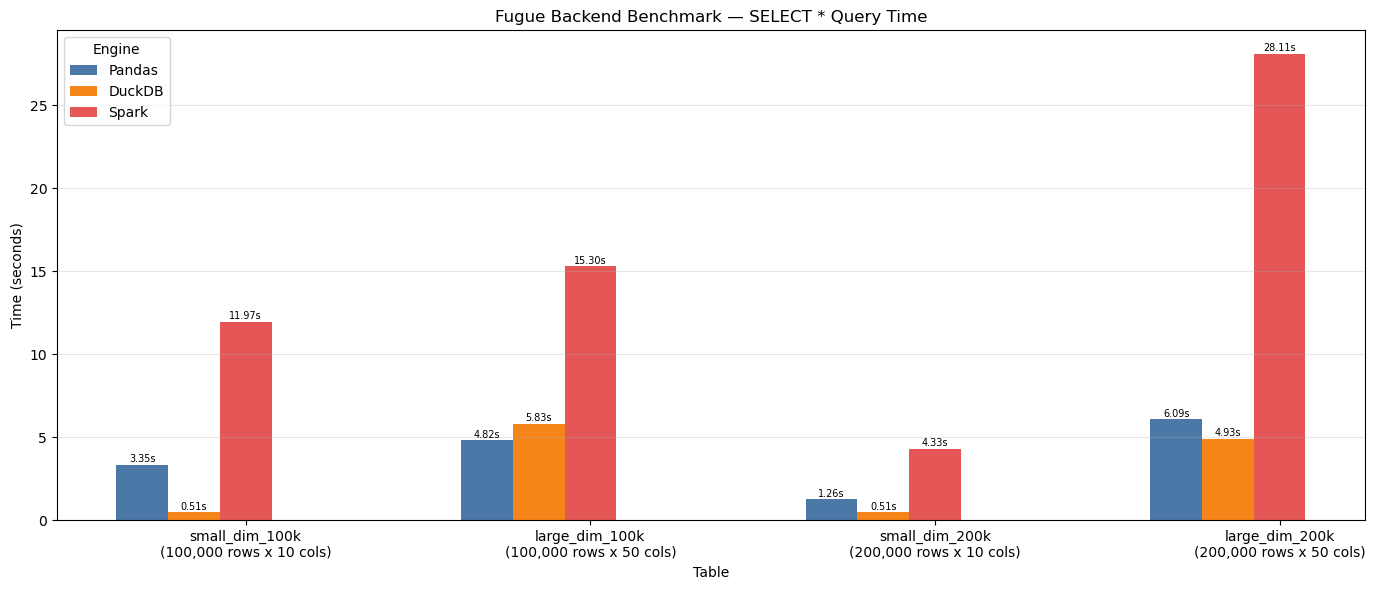

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(TABLE_NAMES))
width = 0.15
colors = ["#4C78A8", "#F58518", "#E45756", "#72B7B2", "#54A24B"]

for i, (label, color) in enumerate(zip(ENGINE_LABELS, colors)):
    times = [pivot.loc[t, label] if pd.notna(pivot.loc[t, label]) else 0 for t in TABLE_NAMES]
    bars = ax.bar(x + i * width, times, width, label=label, color=color)
    for bar, val in zip(bars, times):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                    f"{val:.2f}s", ha="center", va="bottom", fontsize=7)

ax.set_xlabel("Table")
ax.set_ylabel("Time (seconds)")
ax.set_title("Fugue Backend Benchmark — SELECT * Query Time")
ax.set_xticks(x + width * 2)
ax.set_xticklabels([f"{t}\n({tables[t].shape[0]:,} rows x {tables[t].shape[1]} cols)" for t in TABLE_NAMES])
ax.legend(title="Engine")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Fastest Engine Per Table

In [8]:
summary = []
for table_name in TABLE_NAMES:
    row = pivot.loc[table_name].dropna()
    if len(row) > 0:
        fastest_engine = row.idxmin()
        fastest_time = row.min()
        slowest_engine = row.idxmax()
        slowest_time = row.max()
        summary.append({
            "Table": table_name,
            "Rows": f"{tables[table_name].shape[0]:,}",
            "Cols": tables[table_name].shape[1],
            "Fastest": f"{fastest_engine} ({fastest_time:.3f}s)",
            "Slowest": f"{slowest_engine} ({slowest_time:.3f}s)",
            "Speedup": f"{slowest_time / fastest_time:.1f}x",
        })

pd.DataFrame(summary).set_index("Table")

,Rows,Cols,Fastest,Slowest,Speedup
Table,,,,,
small_dim_100k,"100,000",10,DuckDB (0.507s),Spark (11.974s),23.6x
large_dim_100k,"100,000",50,Pandas (4.817s),Spark (15.297s),3.2x
small_dim_200k,"200,000",10,DuckDB (0.510s),Spark (4.329s),8.5x
large_dim_200k,"200,000",50,DuckDB (4.925s),Spark (28.114s),5.7x
